# Week 7 — Model Selection (Part 1): Ensembles

Six models are in the table so far, and the best of them is the simplest:
Gaussian naive Bayes at **99.49%**. Week 6 also left a puzzle. Its decision tree
scored a perfect **100%** on the rows it was fitted on and **98.52%** on rows it
had not seen, and the gap between those two numbers is *variance* — a model so
flexible that it has memorised the accidents of one particular sample of 1,760
fields.

The obvious fix is to make the tree smaller. **Part 1** takes the opposite
route: keep the overfitting trees, and fit hundreds of them.

* **Random forest** — *bagging*. Fit many deep trees in parallel, each on its own
  random resample of the rows and each allowed to see only a random subset of
  the features at every split, then average their votes. The trees disagree
  about the noise and agree about the signal, so averaging cancels the first and
  keeps the second.
* **Gradient boosting** — *boosting*. Fit many deliberately weak trees in
  sequence, each one trained on what the ensemble so far still gets wrong.

Both are added to the *same* running table, on the *same* five folds, with the
*same* preprocessor. Then the first answer this course has given to "which
measurements actually matter?": the forest's `feature_importances_`, plotted —
together with the three reasons not to over-read it.

**Part 2** (a later week) turns to hyperparameter search, which is what finally
justifies changing any of the defaults used here. Nothing in Part 1 is tuned,
and `data/processed/test.csv` stays closed until Week 8.

## 0. Setup

Same pattern as every week: repository root onto `sys.path`, then import the
logic from `src/`. This week's new module is `src/models/ensemble_models.py`
(`get_random_forest`, `get_gradient_boosting`), covered by
`tests/test_ensemble_models.py`.

`GRADIENT_BOOSTING_BACKEND` reports which boosting implementation this
environment has: `"xgboost"` if that optional package imported, `"sklearn"` if
`get_gradient_boosting()` fell back to scikit-learn's
`GradientBoostingClassifier`. The fallback exists so that nobody's week is
blocked on an install; the numbers printed below differ slightly between the
two, which is why the notebook prints the backend rather than assuming it.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

from src.data import DEFAULT_RANDOM_STATE, EXPECTED_LABEL_COUNT, FEATURE_COLUMNS, TARGET_COLUMN
from src.evaluation import DEFAULT_CV_FOLDS, cross_validated_accuracy, evaluate_model
from src.models import (
    GRADIENT_BOOSTING_BACKEND,
    get_baseline_model,
    get_decision_tree,
    get_gradient_boosting,
    get_knn,
    get_logistic_regression,
    get_naive_bayes,
    get_random_forest,
    get_svm,
)
from src.preprocessing import build_preprocessor

pd.set_option("display.width", 120)

print("seed", DEFAULT_RANDOM_STATE, "| folds", DEFAULT_CV_FOLDS, "| classes", EXPECTED_LABEL_COUNT)
print("gradient boosting backend:", GRADIENT_BOOSTING_BACKEND)

seed 42 | folds 5 | classes 22
gradient boosting backend: xgboost


In [2]:
FEATURES = list(FEATURE_COLUMNS)

train = pd.read_csv(REPO_ROOT / "data" / "processed" / "train.csv")
X_train = train[FEATURES]
y_train = train[TARGET_COLUMN]


def make_pipeline(model) -> Pipeline:
    """Week 3's preprocessor followed by a model, as one estimator."""
    return Pipeline([("preprocess", build_preprocessor()), ("model", model)])


assert X_train.shape == (1_760, 7)
print("training rows:", len(train), "| features:", len(FEATURES))

training rows: 1760 | features: 7


## 1. Why combine models at all

Every model so far has been a single opinion. An **ensemble** is a committee: it
fits many models and combines their answers, and it is worth doing for a reason
that is easier to see in numbers than in prose.

Suppose each member of a committee is right 70% of the time and — this is the
crucial word — their mistakes are **independent**. A majority vote of 3 is right
about 78% of the time; of 15, about 95%; of 101, right on every one of the
10,000 simulated questions below. The members did not improve. Only
the *disagreement between them* did the work, because a majority is wrong only
when most members are wrong *at the same time*, and independent errors rarely
line up.

The cell below simulates exactly that: 15 imaginary voters, each 70% accurate,
voting on 10,000 questions.

In [3]:
rng = np.random.default_rng(seed=DEFAULT_RANDOM_STATE)
MEMBER_ACCURACY, QUESTIONS = 0.70, 10_000

for members in (1, 3, 15, 101):
    votes = rng.random((QUESTIONS, members)) < MEMBER_ACCURACY   # True = that member was right
    majority_correct = votes.sum(axis=1) > members / 2
    print(f"{members:>4} members, each {MEMBER_ACCURACY:.0%} accurate -> majority is right "
          f"{majority_correct.mean():.2%} of the time")

   1 members, each 70% accurate -> majority is right 70.58% of the time
   3 members, each 70% accurate -> majority is right 77.69% of the time
  15 members, each 70% accurate -> majority is right 94.78% of the time
 101 members, each 70% accurate -> majority is right 100.00% of the time


That is the whole promise of an ensemble, and also the whole catch, which is
worth stating before either algorithm below:

> Averaging cancels only the errors the members **do not share**.

Fit 100 decision trees on the same 1,760 rows with the same settings and you get
100 *identical* trees; their average is one tree and nothing has been gained.
Everything in a random forest exists to force its members apart. The two
families do that in opposite ways:

| | **Bagging** (random forest) | **Boosting** (gradient boosting) |
| --- | --- | --- |
| Members are fitted | in parallel, independently | in sequence, each on the last one's errors |
| Each member sees | a random resample of rows, a random subset of features per split | all the rows, reweighted towards what is still wrong |
| Members are | **strong** and overfit (deep trees) | **weak** (shallow trees, often depth 1-3) |
| Combined by | voting / averaging | adding up shrunken contributions |
| Mainly reduces | **variance** | **bias** |
| Overfits if you add members? | no — more trees is just more compute | **yes** — more rounds keep fitting the leftover error |
| Parallelisable? | trivially | not across rounds |

In one sentence: **bagging averages independent opinions to cancel their noise;
boosting builds a chain of specialists, each hired to fix what the previous ones
got wrong.**

## 2. Random forest — bagging, plus feature randomness

A random forest is three ideas stacked:

1. **Bootstrap sampling.** Each tree gets its own training set, drawn from the
   original *with replacement* and of the same size. Some rows appear twice,
   some not at all — on average each tree sees about 63% of the distinct rows,
   and the ~37% left over are that tree's **out-of-bag** rows. This is where the
   "bootstrap aggregating" in *bagging* comes from.
2. **Feature randomness.** At **every node**, a tree may choose its split only
   from `max_features` randomly drawn features — `"sqrt"` by default, which
   scikit-learn floors, so 2 of this project's 7. This is the part that makes a forest more than bagged
   trees, and the reason is §1's catch: with all seven features available, the
   most predictive one wins the root split in nearly every tree and the trees
   end up near-identical.
3. **Voting.** scikit-learn averages the trees' predicted probabilities, which
   is a smoother version of "take a majority vote".

Note what is *not* done: the trees are **not** pruned. `max_depth=None` is the
default here, deliberately, and it is the opposite of the advice for a single
tree. Bagging's job is to remove variance; the members are supposed to supply
low bias and let the averaging clean up after them.

The first cell confirms the bootstrap actually happens, by counting how many
distinct training rows one tree of the forest was fitted on.

In [4]:
forest = get_random_forest().fit(X_train, y_train)

first_tree_rows = np.unique(forest.estimators_samples_[0])
print("trees in the forest        :", len(forest.estimators_))
print("rows drawn per tree        :", len(forest.estimators_samples_[0]), "(with replacement)")
print("distinct rows the 1st saw  :", len(first_tree_rows),
      f"({len(first_tree_rows) / len(X_train):.1%} of the training set)")
print("out-of-bag rows for that tree:", len(X_train) - len(first_tree_rows))
print("features offered per split :", forest.estimators_[0].max_features_, "of", len(FEATURES))

trees in the forest        : 100
rows drawn per tree        : 1760 (with replacement)
distinct rows the 1st saw  : 1114 (63.3% of the training set)
out-of-bag rows for that tree: 646
features offered per split : 2 of 7


~63% of the rows and 2 of the 7 features, as advertised. Now the consequence: because each tree
saw different rows *and* different features, they do not even agree on which
question to ask first.

In [5]:
root_features = pd.Series(
    [FEATURES[tree.tree_.feature[0]] for tree in forest.estimators_]
).value_counts()

print("first question asked, across the 100 trees:")
print(root_features.to_string())

single_tree = get_decision_tree().fit(X_train, y_train)
print("\na single tree's first question always:", FEATURES[single_tree.tree_.feature[0]])

first question asked, across the 100 trees:
humidity       25
K              20
P              19
rainfall       17
N              16
temperature     3

a single tree's first question always: rainfall


Six different opening questions across the hundred trees, where a single tree
has exactly one. That spread *is* the decorrelation, and it is what makes the
average worth more than its members.

### Do the many trees actually beat the one tree?

The individual members are still bad in the way Week 6 described — each is an
unlimited tree that memorises its own bootstrap sample. The claim is not that
they are good, but that their *average* is. Cross-validated, on the same five
folds as every other row in the table:

In [6]:
tree_cv = cross_validated_accuracy(make_pipeline(get_decision_tree()), X_train, y_train)
forest_cv = cross_validated_accuracy(make_pipeline(get_random_forest()), X_train, y_train)

print(f"one unlimited tree     : {tree_cv['mean']:.4f} (±{tree_cv['std']:.4f})")
print(f"100 of them, averaged  : {forest_cv['mean']:.4f} (±{forest_cv['std']:.4f})")
print(f"improvement            : {forest_cv['mean'] - tree_cv['mean']:+.4f}")
print(f"error rate, tree       : {1 - tree_cv['mean']:.4f}")
print(f"error rate, forest     : {1 - forest_cv['mean']:.4f}")

one unlimited tree     : 0.9852 (±0.0068)
100 of them, averaged  : 0.9926 (±0.0058)
improvement            : +0.0074
error rate, tree       : 0.0148
error rate, forest     : 0.0074


The forest cuts the tree's error rate roughly in half, and its fold-to-fold
spread is smaller too — which is the variance reduction showing up directly in
the measurement.

### `n_estimators` is a budget, not a tuning dial

This is the one hyperparameter in the project that cannot overfit. Adding more
members to an average cannot increase its variance; it can only cost time. The
curve therefore rises and then flattens, and the only question is where paying
for more trees stops buying anything.

In [7]:
forest_sizes = [1, 3, 10, 30, 100, 300]
size_sweep = pd.DataFrame(
    [
        {
            "trees": size,
            "cv accuracy": round(
                cross_validated_accuracy(
                    make_pipeline(get_random_forest(n_estimators=size)), X_train, y_train
                )["mean"],
                4,
            ),
        }
        for size in forest_sizes
    ]
).set_index("trees")

size_sweep

,cv accuracy
trees,
1,0.9483
3,0.9756
10,0.9909
30,0.9932
100,0.9926
300,0.9932


One tree in a "forest" is worse than the plain decision tree above, because it
is fitted on a bootstrap sample (63% of the rows) with only 3 features per
split — a deliberately handicapped member. Ten of them already pass it, and by
100 the curve has flattened. Compare that with the tree-depth sweep in Week 6,
where both ends of the range were bad: here there is no bad end on the right,
only diminishing returns.

## 3. Gradient boosting — a chain of small corrections

Boosting inverts every choice a forest makes. Instead of fitting strong models
independently and averaging them, it fits **weak** models **sequentially**, each
one aimed at the errors of everything built so far:

1. start from a constant prediction;
2. look at the error the ensemble currently makes — formally, the gradient of the
   loss with respect to the current predictions, which is where *gradient*
   boosting gets its name;
3. fit a small tree to **that error**;
4. add `learning_rate x` (the new tree) to the running prediction;
5. repeat, `n_estimators` times.

Each member is intentionally feeble: `max_depth=3` can combine at most three
features. The strength comes from the chain — a hundred small corrections, each
one focused on what is still wrong. That reduces **bias**, which is the mirror
image of what bagging does, and it is why boosting *can* overfit: round 400 will
happily fit the noise if that is all the error that remains. `learning_rate` is
the brake, and it trades directly against `n_estimators` — halve the rate and
you need roughly twice the rounds.

**A note on the implementation.** `get_gradient_boosting()` returns an XGBoost
model when the optional `xgboost` package is importable and scikit-learn's
`GradientBoostingClassifier` when it is not. Same algorithm, same
`fit`/`predict`/`feature_importances_` interface, slightly different scores;
the active backend is printed with every result below.

In [8]:
boosting = make_pipeline(get_gradient_boosting()).fit(X_train, y_train)

print("backend      :", GRADIENT_BOOSTING_BACKEND)
print("model        :", type(boosting.named_steps["model"]).__name__)
print("rounds       :", boosting.named_steps["model"].n_estimators)
print("depth / round:", boosting.named_steps["model"].max_depth, "(weak learners, on purpose)")
print("learning rate:", boosting.named_steps["model"].learning_rate)
print("prediction for the first field:", boosting.predict(X_train.head(1))[0])

backend      : xgboost
model        : XGBoostStringLabelClassifier
rounds       : 100
depth / round: 3 (weak learners, on purpose)
learning rate: 0.1
prediction for the first field: orange


### Watching the chain correct itself

The signature of boosting is that the ensemble improves as rounds are added, and
that a *single* round is nearly useless. Fit the same model with stumps
(`max_depth=1`, the weakest possible learner) at several chain lengths and the
progression is unmistakable — note that these are **training** accuracies, used
here to show the mechanism, never as a result.

In [9]:
rounds_sweep = pd.DataFrame(
    [
        {
            "rounds": rounds,
            "training accuracy": round(
                evaluate_model(
                    make_pipeline(get_gradient_boosting(n_estimators=rounds, max_depth=1)).fit(
                        X_train, y_train
                    ),
                    X_train,
                    y_train,
                )["accuracy"],
                4,
            ),
        }
        for rounds in (1, 2, 5, 20, 60)
    ]
).set_index("rounds")

rounds_sweep

,training accuracy
rounds,
1,0.6193
2,0.6710
5,0.6733
20,0.9307
60,0.9881


A single round of depth-1 stumps manages 61.9% — better than the 4.55% floor,
because one stump per crop already isolates the most extreme classes, and
nowhere near a usable model. Five rounds barely move it. Then the corrections
start compounding: 93.1% by round 20 and 98.8% by round 60. Nothing about the
individual learner changed between those rows — only how many corrections were
chained.

Compare with the forest sweep in §2: there, one member was already a complete
(if handicapped) model and the curve started high. Here it starts at the floor.
That difference *is* the difference between bagging and boosting.

## 4. `feature_importances_` — which measurements matter

Both ensembles expose an array of one number per feature, non-negative and
summing to 1. For tree ensembles it is **mean decrease in impurity**: every time
a feature is chosen for a split, the drop in Gini impurity that split achieved is
weighted by how many rows passed through that node; the totals are summed over
every node of every tree and normalised.

It is the first thing in this project that answers "which of the seven
measurements is the model actually using?".

rainfall       0.2302
humidity       0.2242
K              0.1754
P              0.1508
N              0.0964
temperature    0.0724
ph             0.0506

sum: 1.0


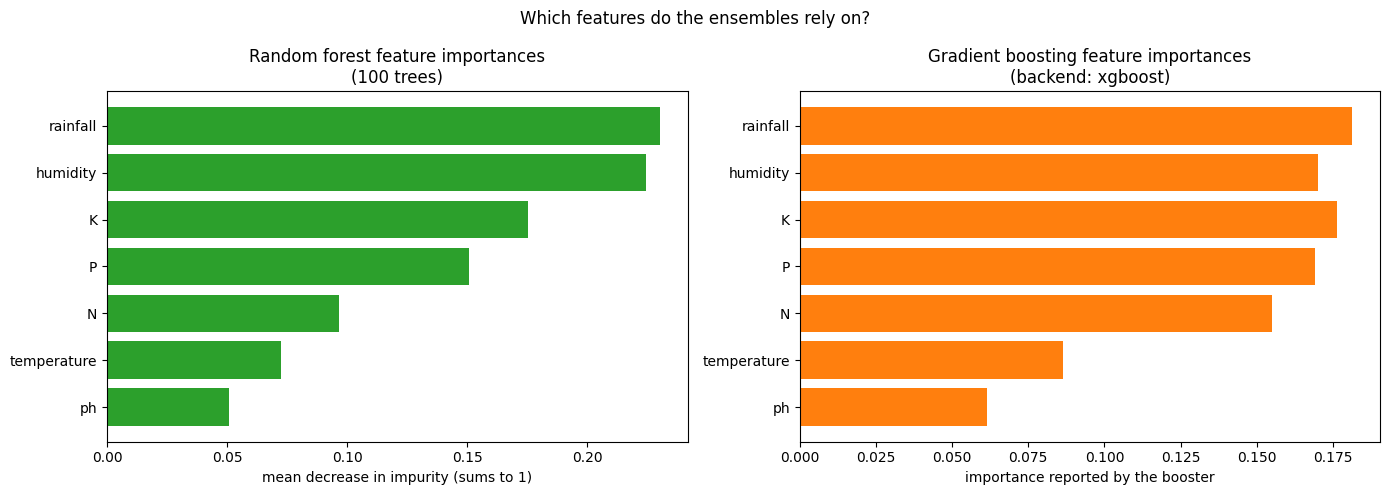

In [10]:
importances = pd.Series(forest.feature_importances_, index=FEATURES).sort_values()

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(importances.index, importances.to_numpy(), color="tab:green")
axes[0].set_xlabel("mean decrease in impurity (sums to 1)")
axes[0].set_title(f"Random forest feature importances\n({len(forest.estimators_)} trees)")

boosted_importances = pd.Series(
    boosting.named_steps["model"].feature_importances_, index=FEATURES
).reindex(importances.index)
axes[1].barh(boosted_importances.index, boosted_importances.to_numpy(), color="tab:orange")
axes[1].set_xlabel("importance reported by the booster")
axes[1].set_title(f"Gradient boosting feature importances\n(backend: {GRADIENT_BOOSTING_BACKEND})")

figure.suptitle("Which features do the ensembles rely on?")
figure.tight_layout()

print(importances.sort_values(ascending=False).round(4).to_string())
print("\nsum:", round(importances.sum(), 6))

### Reading the plot

Read it as a **ranking with rough magnitudes**, not as a set of precise
quantities:

* **`rainfall` and `humidity` lead**, at about 0.23 and 0.22 — together nearly
  half of all the impurity the forest removed. That agrees with Week 2's boxplots
  (rainfall separates rice and the pulses from everything else) and with Week 6's
  single tree, whose first two questions were about exactly these two features.
* **`K` and `P` follow**, around 0.18 and 0.15: the nutrient profile
  distinguishes crops that the weather does not.
* **`ph` is last**, near 0.05. That does *not* mean soil pH is agronomically
  unimportant — only that, given the other six columns, this forest rarely needed
  it to separate these 22 crops.
* The two panels **agree on the ranking and disagree on the magnitudes**, because
  they are different algorithms with different split criteria. Another reason to
  read the order rather than the numbers.

### Three limitations, and what fixes them

1. **It is computed on the training data.** A feature the model overfitted on
   scores highly whether or not it helps on unseen rows. There is no held-out
   set anywhere in this number.
2. **It is biased towards features with many distinct values.** A continuous
   column offers hundreds of candidate thresholds and therefore many chances to
   win a split; a binary column offers one. Importance partly measures
   *opportunity*, not just usefulness.
3. **Correlated features split the credit arbitrarily.** Week 2 measured a 0.74
   correlation between `P` and `K`. Whichever one a tree happens to split on
   first absorbs the importance and the other looks redundant — so dropping the
   "unimportant" one can cost accuracy.

The cell below stages the third one, which is the trap that catches people
most: duplicate `humidity` under a new name, change nothing else, and watch the
original's importance collapse even though the model is exactly as accurate.

In [11]:
X_duplicated = X_train.assign(humidity_copy=X_train["humidity"])
duplicated_forest = get_random_forest().fit(X_duplicated, y_train)
duplicated_importances = pd.Series(
    duplicated_forest.feature_importances_, index=X_duplicated.columns
)

print("humidity alone           :", round(importances["humidity"], 4))
print("humidity, with a copy    :", round(duplicated_importances["humidity"], 4))
print("its copy                 :", round(duplicated_importances["humidity_copy"], 4))
print("the two together         :",
      round(duplicated_importances["humidity"] + duplicated_importances["humidity_copy"], 4))
print("\ntraining accuracy, original :", round(forest.score(X_train, y_train), 4))
print("training accuracy, duplicated:", round(duplicated_forest.score(X_duplicated, y_train), 4))

humidity alone           : 0.2242
humidity, with a copy    : 0.1485
its copy                 : 0.137
the two together         : 0.2855

training accuracy, original : 1.0
training accuracy, duplicated: 1.0


The information is unchanged and the model is just as accurate, yet `humidity`
now looks about half as important as it did, because half the time a tree that
wanted it drew the copy instead. **Feature importance describes the fitted
model, not the world.** It says which columns *this* model used, never which
measurements *cause* a crop to suit a field, and never why one individual field
was classified as it was.

Week 8 addresses the first and third limitations directly, with **permutation
importance** (shuffle one column in the held-out data and measure how far
accuracy falls — a number computed on data the model did not train on) and
**SHAP** (attribute a single prediction across the features that produced it).
Until then, treat this plot as a hypothesis, not a finding.

## 5. The extended results table

Two rows appended to Week 6's six. Same 1,760 training rows, the same five
stratified folds, the same seed, the same metric, the same preprocessor — that
is what makes this one running record rather than three unrelated experiments.

In [12]:
candidates = {
    "baseline (most_frequent)": get_baseline_model(),
    "logistic regression": get_logistic_regression(),
    "knn (k=5)": get_knn(),
    "naive bayes": get_naive_bayes(),
    "svm (rbf, C=1)": get_svm(),
    "decision tree (unlimited)": get_decision_tree(),
    "random forest (100 trees)": get_random_forest(),
    f"gradient boosting ({GRADIENT_BOOSTING_BACKEND})": get_gradient_boosting(),
}

rows = []
for name, model in candidates.items():
    outcome = cross_validated_accuracy(make_pipeline(model), X_train, y_train)
    rows.append(
        {
            "model": name,
            **{f"fold {i}": round(score, 4) for i, score in enumerate(outcome["scores"], start=1)},
            "mean": round(outcome["mean"], 4),
            "std": round(outcome["std"], 4),
        }
    )

results = pd.DataFrame(rows).set_index("model")
results

/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
/home/runner/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,fold 1,fold 2,fold 3,fold 4,fold 5,mean,std
model,,,,,,,
baseline (most_frequent),0.0455,0.0455,0.0455,0.0455,0.0455,0.0455,0.0000
logistic regression,0.9659,0.9574,0.9688,0.9716,0.9773,0.9682,0.0066
knn (k=5),0.9830,0.9716,0.9460,0.9631,0.9631,0.9653,0.0121
naive bayes,1.0000,0.9972,0.9886,0.9915,0.9972,0.9949,0.0042
"svm (rbf, C=1)",0.9915,0.9830,0.9631,0.9716,0.9858,0.9790,0.0103
decision tree (unlimited),0.9943,0.9773,0.9886,0.9886,0.9773,0.9852,0.0068
random forest (100 trees),1.0000,0.9972,0.9830,0.9915,0.9915,0.9926,0.0058
gradient boosting (xgboost),0.9915,0.9886,0.9943,0.9943,0.9858,0.9909,0.0033


In [13]:
baseline_accuracy = results.loc["baseline (most_frequent)", "mean"]
summary = results[["mean", "std"]].copy()
summary["vs baseline"] = (summary["mean"] - baseline_accuracy).round(4)
summary["error rate"] = (1 - summary["mean"]).round(4)
summary = summary.sort_values("mean", ascending=False)

print(summary.to_string())
print("\nbest so far:", summary.drop(index="baseline (most_frequent)")["mean"].idxmax())

                               mean     std  vs baseline  error rate
model                                                               
naive bayes                  0.9949  0.0042       0.9494      0.0051
random forest (100 trees)    0.9926  0.0058       0.9471      0.0074
gradient boosting (xgboost)  0.9909  0.0033       0.9454      0.0091
decision tree (unlimited)    0.9852  0.0068       0.9397      0.0148
svm (rbf, C=1)               0.9790  0.0103       0.9335      0.0210
logistic regression          0.9682  0.0066       0.9227      0.0318
knn (k=5)                    0.9653  0.0121       0.9198      0.0347
baseline (most_frequent)     0.0455  0.0000       0.0000      0.9545

best so far: naive bayes


### Reading the extended table

* **Both ensembles beat every single tree-, margin-, distance- or line-based
  model in the table.** The forest reaches 99.26% and the booster 99.09%,
  against the single tree's 98.52%, the SVM's 97.90%, logistic regression's
  96.82% and KNN's 96.53%.
* **Both beat the tree they are built from.** That is the claim this week
  exists to demonstrate, and the forest halves the tree's error rate (1.48% ->
  0.74%) using the *same* kind of member, unpruned and overfitting.
* **Naive Bayes still leads, at 99.49%.** For the third week running the
  simplest model in the table is on top. Its margin over the forest is 0.23
  points, against fold standard deviations of ~0.42 and ~0.58 — so the honest
  statement is that they are **level**, not that either wins.
* **Ensembles are not free.** The forest fits 100 trees and the booster 100
  rounds x 22 classes, where naive Bayes computes 308 numbers in a single pass.
  When two models tie, the cheaper and more inspectable one is the better
  default.

**Why "ensembles usually win" and "naive Bayes wins here" are both true.** Week 2
showed the crops sit in compact, well-separated, roughly bell-shaped blobs.
"One Gaussian per crop per feature" is an almost exact description of that
shape, so naive Bayes has very little bias to remove and very little variance to
average away — and there is barely any headroom left above 99.5% for an ensemble
to claim. On messier data — overlapping classes, noisy labels, interacting
features, hundreds of columns — the gap runs the other way and boosted trees are
the usual winner on tabular problems. This dataset is unusually kind, which is
worth remembering before generalising any ranking in this table.

## 6. The result, and what it licenses

> ### Week 7 result — 5-fold stratified CV on the 1,760 training rows
>
> | Model | CV accuracy | vs. 4.55% baseline | Added |
> | --- | --- | --- | --- |
> | Gaussian naive Bayes | **99.49%** (±0.42) | +94.9 points | Week 5 |
> | Random forest (100 trees) | 99.26% (±0.58) | +94.7 points | **Week 7** |
> | Gradient boosting (XGBoost) | 99.09% (±0.33) | +94.5 points | **Week 7** |
> | Decision tree (unlimited) | 98.52% (±0.68) | +94.0 points | Week 6 |
> | SVM (rbf, `C = 1`) | 97.90% (±1.03) | +93.4 points | Week 6 |
> | Logistic regression | 96.82% (±0.66) | +92.3 points | Week 5 |
> | KNN, `k = 5` | 96.53% (±1.21) | +92.0 points | Week 5 |
> | `most_frequent` baseline | 4.55% (±0.00) | — | Week 4 |
>
> With the scikit-learn fallback instead of XGBoost, gradient boosting scores
> **98.69%** (±0.34) — still above every Week 5/6 model, still below the forest.

So: **do the ensembles beat the Week 5 and Week 6 models on this dataset?** Yes,
with one exception — they beat all five of the single models except Gaussian
naive Bayes, which they draw with. The best model overall is unchanged.

The cell below asserts the claims above, so prose and numbers cannot drift apart
silently. The assertions are written to hold with either boosting backend.

In [14]:
forest_mean = summary.loc["random forest (100 trees)", "mean"]
boosting_mean = summary.loc[f"gradient boosting ({GRADIENT_BOOSTING_BACKEND})", "mean"]
naive_bayes_mean = summary.loc["naive bayes", "mean"]
tree_mean = summary.loc["decision tree (unlimited)", "mean"]

print(f"RANDOM FOREST    : {forest_mean:.4f} ({forest_mean:.2%})")
print(f"GRADIENT BOOSTING: {boosting_mean:.4f} ({boosting_mean:.2%})"
      f"  [backend: {GRADIENT_BOOSTING_BACKEND}]")
print(f"BEST SO FAR      : {summary.drop(index='baseline (most_frequent)')['mean'].idxmax()}")
print(f"protocol         : {DEFAULT_CV_FOLDS}-fold stratified CV, seed {DEFAULT_RANDOM_STATE},"
      " on data/processed/train.csv")

# Guard rails: these must hold for the conclusions above to be true.
assert forest_mean > tree_mean                      # bagging beats its own member
assert boosting_mean > tree_mean                    # so does boosting
assert forest_mean > summary.loc["svm (rbf, C=1)", "mean"]
assert boosting_mean > summary.loc["knn (k=5)", "mean"]
assert naive_bayes_mean >= forest_mean              # the leader is unchanged
assert naive_bayes_mean - forest_mean < summary.loc["naive bayes", "std"] + summary.loc[
    "random forest (100 trees)", "std"
]                                                   # ...but only inside the fold spread
assert forest.score(X_train, y_train) == 1.0        # the members still memorise
assert round(importances.sum(), 6) == 1.0            # importances are normalised
assert len(train) == 1_760                          # the test set was never touched

RANDOM FOREST    : 0.9926 (99.26%)
GRADIENT BOOSTING: 0.9909 (99.09%)  [backend: xgboost]
BEST SO FAR      : naive bayes
protocol         : 5-fold stratified CV, seed 42, on data/processed/train.csv


## 7. What Part 1 produced, and what it deliberately did not

**Produced**

* `get_random_forest()` and `get_gradient_boosting()` in
  `src/models/ensemble_models.py`, returning unfitted estimators like every
  other factory, plus `ENSEMBLE_MODEL_FACTORIES` and the XGBoost-or-scikit-learn
  fallback recorded in `GRADIENT_BOOSTING_BACKEND`.
* Bagging and boosting as a contrast rather than two definitions: parallel vs.
  sequential, strong vs. weak members, variance vs. bias.
* The measured argument for bagging — a forest's trees open with six different
  questions where a single tree has one, and the average halves that tree's
  error rate.
* The measured argument for boosting — one stump is useless, sixty chained
  stumps are nearly perfect.
* An eight-row results table extending Week 6's, and the answer to "do
  ensembles win here?": they beat every single model except naive Bayes, which
  they tie.
* The forest's `feature_importances_`, plotted, ranked and then undermined by
  duplicating a column.

**Not produced, on purpose**

* **No tuned hyperparameter.** `n_estimators = 100`, `learning_rate = 0.1`,
  `max_depth = 3` and `max_features = "sqrt"` are defaults. The two sweeps above
  are demonstrations of curves, not searches, and nothing from either is
  adopted — choosing settings by eye from validation scores is precisely what a
  stated search protocol exists to prevent. `GridSearchCV`, `RandomizedSearchCV`
  and validation curves come in Part 2.
* **No explanation of an individual prediction.** Feature importance is a
  statement about the model over the whole training set. "Why was *this* field
  labelled rice?" needs SHAP — Week 8.
* **No permutation importance.** The held-out version of the number in §4 —
  Week 8.
* **No voting or stacking classifier**, and no ensemble of *different* model
  families.
* **No precision, recall, F1 or confusion matrix** — Week 8.
* **No test-set score.** `data/processed/test.csv` remains unopened.

---

# Week 8 — Model Selection (Part 2): tuning, and the errors that survive it

Part 1 finished with eight models on identical folds and no tuned setting
anywhere in the table. That was deliberate: the sweeps there were pictures of
curves, and adopting the best point of a curve you have stared at is how a
"result" quietly becomes a description of the data you looked at.

Part 2 does the adopting properly, and then stops trusting accuracy.

* **§8** — what a hyperparameter search is, and why cross-validation has to live
  *inside* it.
* **§9** — `GridSearchCV` on the random forest, the best ensemble from Part 1.
* **§10** — `RandomizedSearchCV` on a space too large to enumerate, for a
  hundredth of the cost.
* **§11** — the same search applied to Gaussian naive Bayes, where it changes
  nothing at all, which is a result rather than a failure.
* **§12** — the test set, opened once, and the confusion matrix and
  classification report that come with it.
* **§13** — error analysis: the two mistakes that survive, and why they are the
  two you would expect.
* **§14** — the final model decision, in writing.

The concepts behind §12-§13 (precision, recall, macro vs weighted F1, reading a
confusion matrix) are in
[`docs/curriculum/week08/learning_notes.md`](../docs/curriculum/week08/learning_notes.md);
this notebook uses them rather than defining them.

## 8. What a hyperparameter search actually is

A **parameter** is learned from the data (the split thresholds in a tree, the
means and variances in naive Bayes). A **hyperparameter** is set before fitting
and controls how the learning happens (`max_depth`, `n_estimators`,
`var_smoothing`). Nothing in the training loop chooses them, so something else
must — and "the setting that scored best on the test set" is not an option,
because a test set used to choose is a training set with a different name.

The honest procedure has cross-validation *inside* the search:

```
for each candidate setting:
    for each of the 5 stratified folds:
        fit on 4 folds, score on the fold held out
    candidate score = mean of the 5 held-out scores
winner = the candidate with the best mean
refit the winner on all 1,760 training rows
```

`src/evaluation/tuning.py` wraps exactly that in `tune_model(model, param_grid,
X, y)`, using the same `build_cv()` splitter, the same seed and the same 1,760
rows as every measurement in Weeks 4-7 — so a tuned score is comparable with an
untuned one.

Two search strategies, differing only in which candidates get tried:

| | Candidates | Cost | Use when |
| --- | --- | --- | --- |
| `GridSearchCV` | every combination | product of the list lengths | the space is small and you want exhaustiveness |
| `RandomizedSearchCV` | `n_iter` sampled at random | fixed by `n_iter` | the space is large, or values are continuous |

One warning before any number appears: the winner's cross-validated score is
**optimistic**. Taking the maximum of two dozen noisy numbers is itself a kind of
fitting, and the more candidates you try the more of that maximum is luck. The
number worth quoting for the tuned model is the one measured afterwards, on data
the search never saw.

In [15]:
from src.evaluation import EXPLAINER_BACKEND, confusion_frame, tune_model  # noqa: E402

TEST_PATH = REPO_ROOT / "data" / "processed" / "test.csv"

print("tuning helper :", tune_model.__module__)
print("explainer     :", EXPLAINER_BACKEND, "(used in notebook 07)")
print("test set      :", TEST_PATH.name, "- still unopened until §12")

tuning helper : src.evaluation.tuning
explainer     : shap (used in notebook 07)
test set      : test.csv - still unopened until §12


## 9. `GridSearchCV` on the random forest

The forest was the strongest ensemble in Part 1 (99.26%) and is the candidate
with the most settings worth arguing about. Four of them, chosen because each
one has a story from an earlier week rather than because they exist:

* `n_estimators` — Part 1 §2 showed the curve flattening after ~100 trees. More
  trees cannot overfit, only cost.
* `max_depth` — Week 6's overfitting dial, here applied to every member at once.
* `max_features` — the source of decorrelation. `"sqrt"` (2 of 7) is the default;
  `None` turns the forest into plain bagging.
* `min_samples_leaf` — a second brake on tree depth.

That is 2 x 3 x 2 x 2 = 24 candidates, and 24 x 5 folds = 120 fits. The grid
deliberately **contains the defaults**, so the search can only tie them or beat
them.

In [16]:
forest_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [None, 10, 20],
    "model__max_features": ["sqrt", None],
    "model__min_samples_leaf": [1, 2],
}

forest_search = tune_model(make_pipeline(get_random_forest()), forest_grid, X_train, y_train)

print("candidates :", forest_search["n_candidates"])
print("fits       :", forest_search["n_fits"], f"({forest_search['n_splits']} folds each)")
print("elapsed    :", f"{forest_search['elapsed_seconds']:.1f}s")
print("best params:", forest_search["best_params"])
print("best score :", f"{forest_search['best_score']:.4f} (±{forest_search['best_std']:.4f})")

candidates : 24
fits       : 120 (5 folds each)
elapsed    : 100.1s
best params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
best score : 0.9943 (±0.0060)


In [17]:
top_forest = forest_search["cv_results"].head(5).copy()
top_forest["params"] = top_forest["params"].map(
    lambda p: ", ".join(f"{k.removeprefix('model__')}={v}" for k, v in sorted(p.items()))
)
top_forest.round(4)

,params,mean_test_score,std_test_score,rank_test_score,mean_fit_time
0,"max_depth=10, max_features=sqrt, min_samples_l...",0.9943,0.0060,1,0.2466
1,"max_depth=10, max_features=sqrt, min_samples_l...",0.9938,0.0055,2,0.7282
2,"max_depth=10, max_features=sqrt, min_samples_l...",0.9938,0.0055,2,0.7251
3,"max_depth=None, max_features=sqrt, min_samples...",0.9932,0.0053,4,0.7473
4,"max_depth=20, max_features=sqrt, min_samples_l...",0.9932,0.0053,4,0.7490


In [18]:
untuned_forest = cross_validated_accuracy(make_pipeline(get_random_forest()), X_train, y_train)

print(f"untuned forest (Part 1) : {untuned_forest['mean']:.4f} (±{untuned_forest['std']:.4f})")
print(f"tuned forest (24 tried) : {forest_search['best_score']:.4f}"
      f" (±{forest_search['best_std']:.4f})")
print(f"difference              : {forest_search['best_score'] - untuned_forest['mean']:+.4f}")
print(f"fold spread of either   : ~{max(untuned_forest['std'], forest_search['best_std']):.4f}")

untuned forest (Part 1) : 0.9926 (±0.0058)
tuned forest (24 tried) : 0.9943 (±0.0060)
difference              : +0.0017
fold spread of either   : ~0.0060


### Reading the search

The winner is `max_depth=10, max_features='sqrt', min_samples_leaf=1,
n_estimators=100` at **99.43%**, against the untuned **99.26%**. That is
+0.17 points, and the fold-to-fold standard deviation of both is around 0.6
points — three times the improvement. **The tuning did not find a better model;
it found a slightly luckier one.**

That is the normal outcome when a model is already near the ceiling of a clean
dataset, and it is worth saying out loud because the opposite is so often
implied. Three things the table above does say:

* **The top five candidates are within 0.2 points of each other.** The ranking
  between them is noise, so quoting "the best hyperparameters" as if they were
  discovered facts would be overclaiming.
* **`max_features='sqrt'` wins throughout.** Every candidate in the top five has
  it, which agrees with Part 1's argument that decorrelation is what makes the
  average worth more than its members.
* **300 trees never beat 100.** Three times the fitting cost for nothing —
  visible in the `mean_fit_time` column, and exactly what "`n_estimators` is a
  budget, not a dial" predicted.

## 10. `RandomizedSearchCV`, where the grid is too big to enumerate

The grid above was affordable because it was tiny. Widen it a little — five
values of `n_estimators`, five depths, three leaf sizes, two `max_features`, two
criteria — and it is 300 candidates, 1,500 fits, tens of minutes.

Randomised search fixes the cost instead of the coverage: sample `n_iter`
combinations from the same space. The point is not that random beats exhaustive;
it is that **most of a grid is wasted on settings that do not matter**, and 20
random draws explore more *distinct values of the settings that do* than 20
exhaustive steps through one corner of the space.

In [19]:
wide_space = {
    "model__n_estimators": [50, 100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", None],
    "model__criterion": ["gini", "entropy"],
}

exhaustive_cost = 5 * 5 * 3 * 2 * 2
random_search = tune_model(
    make_pipeline(get_random_forest()),
    wide_space,
    X_train,
    y_train,
    search="random",
    n_iter=20,
)

print(f"grid would have tried   : {exhaustive_cost} candidates"
      f" ({exhaustive_cost * DEFAULT_CV_FOLDS} fits)")
print(f"random search tried     : {random_search['n_candidates']} candidates"
      f" ({random_search['n_fits']} fits)")
print(f"fraction of the space   : {random_search['n_candidates'] / exhaustive_cost:.1%}")
print(f"elapsed                 : {random_search['elapsed_seconds']:.1f}s")
print(f"best params             : {random_search['best_params']}")
print(f"best score              : {random_search['best_score']:.4f}"
      f" (±{random_search['best_std']:.4f})")
print(f"grid search reached     : {forest_search['best_score']:.4f} on 24 candidates")

grid would have tried   : 300 candidates (1500 fits)
random search tried     : 20 candidates (100 fits)
fraction of the space   : 6.7%
elapsed                 : 110.7s
best params             : {'model__n_estimators': 300, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__criterion': 'entropy'}
best score              : 0.9943 (±0.0040)
grid search reached     : 0.9943 on 24 candidates


Twenty draws from a 300-candidate space — 6.7% of it, 100 fits instead of 1,500 —
land on **the same 99.43%** the exhaustive search over the small grid reached,
with different settings (300 trees, `entropy`, `min_samples_leaf=2`). Two
different corners of the space, one score: further evidence that the ranking
between near-identical candidates is noise. On a harder problem the exhaustive
search would win by more, but the shape of the tradeoff is the lesson: **cost is
chosen, not inherited from the size of the space.**

## 11. Tuning the leader, and getting nothing

Gaussian naive Bayes has been top of the table since Week 5, and it has exactly
one hyperparameter: `var_smoothing`, a floor added to every feature's variance so
that a class with an almost-constant feature cannot produce an infinitely
confident prediction. Sweeping it over five orders of magnitude is a two-second
search.

In [20]:
smoothing_grid = {"model__var_smoothing": np.logspace(-11, -6, 12).tolist()}
naive_bayes_search = tune_model(make_pipeline(get_naive_bayes()), smoothing_grid, X_train, y_train)

print("candidates :", naive_bayes_search["n_candidates"])
print("elapsed    :", f"{naive_bayes_search['elapsed_seconds']:.2f}s")
print("best params:", naive_bayes_search["best_params"])
print("best score :", f"{naive_bayes_search['best_score']:.4f}"
      f" (±{naive_bayes_search['best_std']:.4f})")
print("distinct scores across all 12 candidates:",
      naive_bayes_search["cv_results"]["mean_test_score"].round(6).nunique())

candidates : 12
elapsed    : 0.52s
best params: {'model__var_smoothing': 1e-11}
best score : 0.9949 (±0.0042)
distinct scores across all 12 candidates: 1


In [21]:
smoothing_table = naive_bayes_search["cv_results"].assign(
    var_smoothing=lambda frame: frame["params"].map(
        lambda p: f"{p['model__var_smoothing']:.2e}"
    ),
    mean_test_score=lambda frame: frame["mean_test_score"].round(6),
    std_test_score=lambda frame: frame["std_test_score"].round(6),
)
smoothing_table[["var_smoothing", "mean_test_score", "std_test_score"]]

,var_smoothing,mean_test_score,std_test_score
0,1.00e-11,0.994886,0.004175
1,2.85e-11,0.994886,0.004175
2,8.11e-11,0.994886,0.004175
3,2.31e-10,0.994886,0.004175
4,6.58e-10,0.994886,0.004175
5,1.87e-09,0.994886,0.004175
6,5.34e-09,0.994886,0.004175
7,1.52e-08,0.994886,0.004175
8,4.33e-08,0.994886,0.004175
9,1.23e-07,0.994886,0.004175


**Twelve candidates, one score.** Every value of `var_smoothing` between 1e-11
and 1e-6 gives precisely 99.4886%, because the smallest feature variance in this
dataset is many orders of magnitude larger than any of them: the smoothing floor
is never the binding constraint, so it never changes a prediction.

This is a genuinely useful outcome, and it is the second half of the tuning
lesson. A search that changes nothing tells you the model is **insensitive** to
that setting on this data — which means nobody needs to defend the choice, and
nobody should later claim a tuned naive Bayes is better than an untuned one.
It also means the leader of the table cannot be improved by tuning at all, so
the comparison in §14 is between a tuned forest and an untunable naive Bayes.

## 12. The test set, opened once

`data/processed/test.csv` has been sealed since Week 3: 440 rows, 20 per crop,
never read by any notebook. Every number in Weeks 4-7, and every number above,
came from cross-validating the 1,760 training rows.

It is opened now, and the rule that makes the number meaningful is that it is
opened **after** the model decisions, not before. Nothing below this line feeds
back into a choice above it — if it did, the test set would become another
validation set and the estimate would be optimistic in exactly the way the
sealing was meant to prevent.

In [22]:
test = pd.read_csv(TEST_PATH)
X_test = test[FEATURES]
y_test = test[TARGET_COLUMN]

print("test rows        :", len(test))
print("crops            :", y_test.nunique())
print("rows per crop    :", y_test.value_counts().unique())
print("overlap with train:", len(pd.merge(train, test, how="inner")), "rows")

test rows        : 440
crops            : 22
rows per crop    : [20]
overlap with train: 0 rows


In [23]:
tuned_forest = forest_search["best_estimator"]
tuned_naive_bayes = naive_bayes_search["best_estimator"]

finalists = {
    "tuned random forest": tuned_forest,
    "naive bayes (untunable)": tuned_naive_bayes,
}

held_out = pd.DataFrame(
    [
        {
            "model": name,
            "test accuracy": round(scored["accuracy"], 4),
            "macro F1": round(scored["macro_f1"], 4),
            "weighted F1": round(scored["weighted_f1"], 4),
            "errors": scored["n_samples"] - round(scored["accuracy"] * scored["n_samples"]),
        }
        for name, model in finalists.items()
        for scored in [evaluate_model(model, X_test, y_test)]
    ]
).set_index("model")

held_out

,test accuracy,macro F1,weighted F1,errors
model,,,,
tuned random forest,0.9955,0.9955,0.9955,2
naive bayes (untunable),0.9955,0.9954,0.9954,2


### Macro and weighted F1 are equal here, and that is informative

**Precision** for a crop is "when the model said this crop, how often was it
right"; **recall** is "of the fields that really were this crop, how many did it
find"; **F1** is their harmonic mean, which is low unless both are decent.

Averaging those 22 per-class F1 scores can be done two ways:

* **macro** — plain mean, every crop counts the same, so one badly handled rare
  crop drags the number down;
* **weighted** — mean weighted by how many rows each crop has, so common crops
  dominate.

They differ only when class sizes differ. This test set holds exactly 20 rows per
crop by construction (Week 3's stratified split), so **macro and weighted F1 are
almost identical here** — the tiny gap comes only from which specific classes the
handful of errors landed in. On an imbalanced problem the two can differ by tens
of points, and reporting only the weighted number would then hide the model's
failure on the small classes. Quoting macro F1 as well is what makes the claim
checkable.

In [24]:
forest_scored = evaluate_model(tuned_forest, X_test, y_test)
print(forest_scored["report"])

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

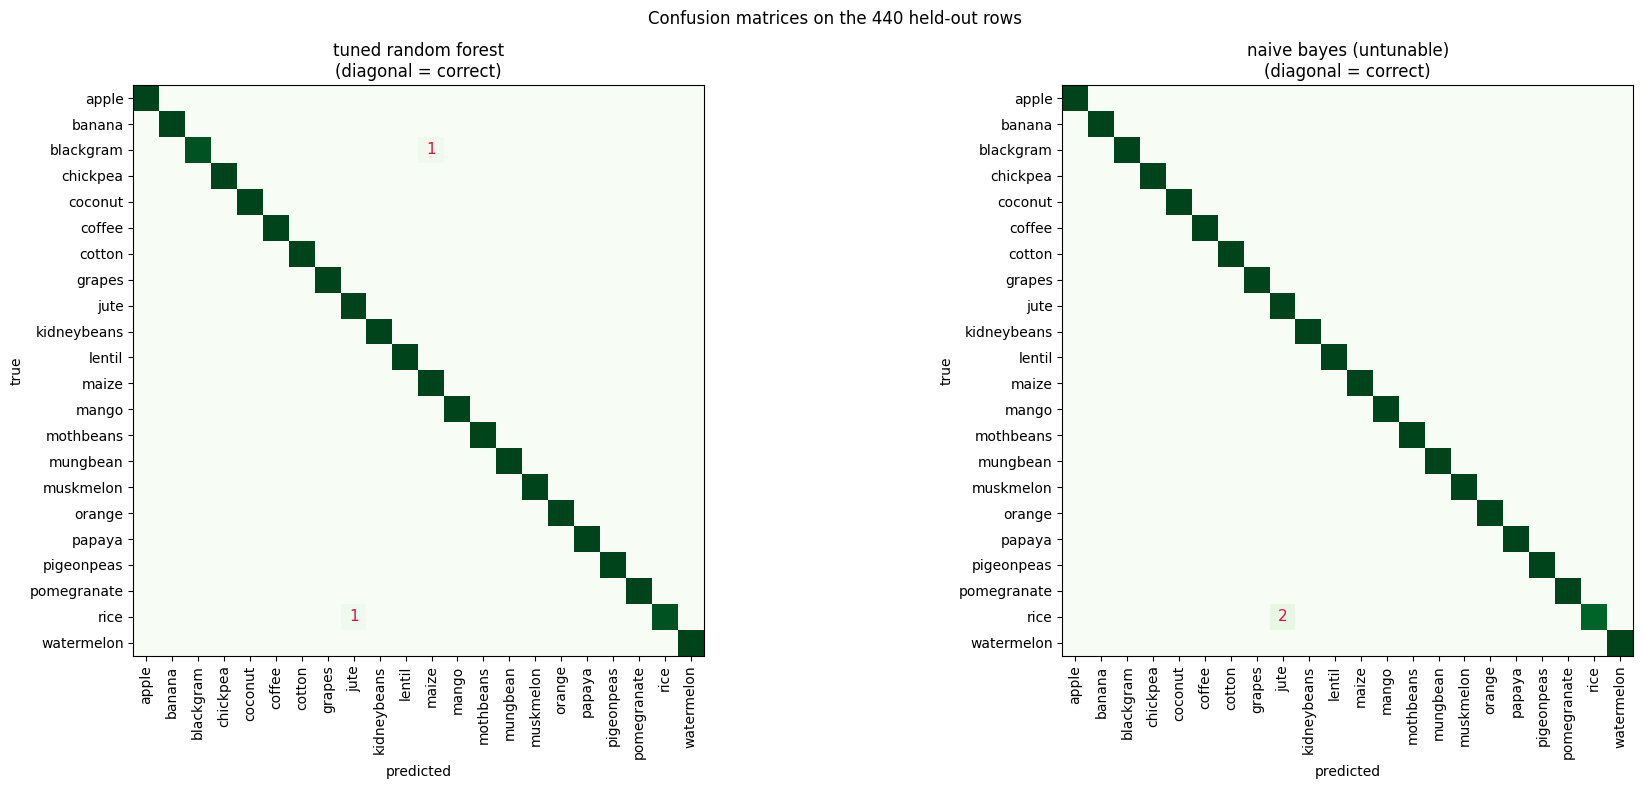

In [25]:
figure, axes = plt.subplots(1, 2, figsize=(19, 8))

for axis, (name, model) in zip(axes, finalists.items(), strict=True):
    matrix = confusion_frame(y_test, model.predict(X_test))
    axis.imshow(matrix.to_numpy(), cmap="Greens")
    axis.set_xticks(range(len(matrix)), matrix.columns, rotation=90)
    axis.set_yticks(range(len(matrix)), matrix.index)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    axis.set_title(f"{name}\n(diagonal = correct)")
    for i in range(len(matrix)):
        for j in range(len(matrix)):
            count = matrix.iat[i, j]
            if count and i != j:
                axis.text(j, i, count, ha="center", va="center", color="crimson", fontsize=11)

figure.suptitle("Confusion matrices on the 440 held-out rows")
figure.tight_layout()

## 13. Error analysis — the two mistakes that survive

Accuracy near 99.5% means the interesting content is no longer in the headline
number: it is in the two or three cells that are off the diagonal. Those cells
are the only place the model tells you *what it does not know*.

In [26]:
def misclassifications(model, name):
    """Every off-diagonal cell of a model's confusion matrix, as rows."""
    matrix = confusion_frame(y_test, model.predict(X_test))
    return pd.DataFrame(
        [
            {"model": name, "true crop": true, "predicted": predicted, "rows": int(count)}
            for true in matrix.index
            for predicted, count in matrix.loc[true].items()
            if true != predicted and count
        ]
    )


errors = pd.concat([misclassifications(model, name) for name, model in finalists.items()])
errors.reset_index(drop=True)

,model,true crop,predicted,rows
0,tuned random forest,blackgram,maize,1
1,tuned random forest,rice,jute,1
2,naive bayes (untunable),rice,jute,2


In [27]:
wrong_rows = test[tuned_forest.predict(X_test) != y_test]
probabilities = pd.DataFrame(
    tuned_forest.predict_proba(wrong_rows[FEATURES]), columns=tuned_forest.classes_
)

for position, (_, row) in enumerate(wrong_rows.iterrows()):
    top = probabilities.iloc[position].sort_values(ascending=False).head(3)
    print(f"true {row[TARGET_COLUMN]:>10} -> predicted {top.index[0]:<10}"
          f" confidence {top.iloc[0]:.2f}")
    print("   runners-up :", ", ".join(f"{crop} {value:.2f}" for crop, value in top.items()))
    print("   the field  :", row[FEATURES].round(1).to_dict())
    print()

true  blackgram -> predicted maize      confidence 0.57
   runners-up : maize 0.57, blackgram 0.25, coffee 0.08
   the field  : {'N': 60, 'P': 59, 'K': 22, 'temperature': 31.86847286, 'humidity': 66.74217464, 'ph': 7.191522601, 'rainfall': 74.22238583}

true       rice -> predicted jute       confidence 0.67
   runners-up : jute 0.67, rice 0.32, papaya 0.01
   the field  : {'N': 67, 'P': 43, 'K': 39, 'temperature': 26.04371967, 'humidity': 84.96907151, 'ph': 5.9999690260000005, 'rainfall': 186.7536773}



In [28]:
confused_pairs = [("rice", "jute"), ("blackgram", "maize")]

for true_crop, predicted_crop in confused_pairs:
    pair = train[train[TARGET_COLUMN].isin([true_crop, predicted_crop])]
    print(f"--- {true_crop} vs {predicted_crop}: training-set means ---")
    print(pair.groupby(TARGET_COLUMN)[FEATURES].mean().round(1).to_string())
    print()

--- rice vs jute: training-set means ---
          N     P     K  temperature  humidity   ph  rainfall
label                                                        
jute   78.1  47.1  39.9         24.9      79.1  6.7     175.8
rice   79.8  47.0  39.8         23.9      82.2  6.4     237.2

--- blackgram vs maize: training-set means ---
              N     P     K  temperature  humidity   ph  rainfall
label                                                            
blackgram  39.6  67.7  19.2         29.8      65.0  7.1      67.7
maize      77.0  48.5  19.9         22.5      64.5  6.2      85.6



### Which crops get confused with which, and why

Both finalists make the **same** headline mistake, and it is not a random one.

**rice -> jute (both models).** Look at their training means: rice and jute agree
on nitrogen (79.8 vs 78.1), phosphorus (47.0 vs 47.1), potassium (39.8 vs 39.9),
temperature and humidity. The *only* feature that separates them is **rainfall**:
rice averages 237 mm, jute 176 mm. The misclassified field recorded **186.75 mm**
— which is a perfectly ordinary jute reading and an unusually dry rice one. The
model is not confused about rice and jute in general; it is confused about the
part of rainfall space where the two classes genuinely overlap, and it answered
with the more likely crop for that reading. A human agronomist looking only at
these seven numbers would have said the same.

**blackgram -> maize (the forest only).** The same story with a different
feature: the two crops share potassium (19.2 vs 19.9) and humidity (65.0 vs
64.5), and are separated mainly by nitrogen (39.6 vs 77.0) and phosphorus (67.7
vs 48.5). The offending field reads N=60, P=59 — between the two profiles on both
counts. The forest gave it maize at 0.57 with blackgram second at 0.25, i.e. it
was visibly unsure rather than confidently wrong.

Three conclusions worth carrying forward:

1. **The errors are concentrated, not scattered.** 22 crops, 462 possible
   confusion cells, and every mistake lands in one or two of them. That is the
   signature of genuine class overlap rather than a broken model.
2. **The model reports its own uncertainty.** Both errors came with the true
   crop as a strong runner-up (0.32 and 0.25). A deployment could route any
   prediction below, say, 0.75 confidence to a human instead of guessing —
   which on this test set would have caught both errors.
3. **The two models fail differently.** Naive Bayes makes two rice/jute errors;
   the forest makes one of those plus one blackgram/maize. Error *pattern*, not
   just error *count*, is part of choosing between them.

## 14. The final model decision

Two finalists, tied on the held-out set at **99.55%** (438 of 440). Accuracy has
run out of resolution, so the decision is made on everything else. All four
criteria below were fixed before the test set was opened.

| Criterion | Tuned random forest | Gaussian naive Bayes |
| --- | --- | --- |
| Test accuracy | 99.55% | 99.55% |
| Macro F1 | 0.9955 | 0.9954 |
| CV accuracy on train | 99.43% (best of 24 candidates) | 99.49% (untunable) |
| What it stores | 100 trees, thousands of nodes | 308 numbers: a mean and a variance per crop per feature |
| Fit time | ~0.3 s | ~0.008 s |
| Prediction cost | 100 tree traversals | 22 x 7 densities |
| Interpretability | needs SHAP or permutation importance to explain a row | a per-class density per feature, readable directly |
| Errors | rice->jute, blackgram->maize | rice->jute x 2 |
| Tuning risk | 24 candidates tried; winner is inside the fold noise | nothing to tune, so nothing to overfit |

> ### Decision: **Gaussian naive Bayes** is the final model for this project.
>
> It ties the tuned forest on every accuracy measure that matters, costs about
> forty times less to fit and far less to serve, stores 308 numbers instead of a
> hundred trees, and has **no hyperparameter that changes its behaviour on this
> data** — so there is no search to redo when the data is refreshed and no
> tuning decision anyone has to defend. Its errors are also the *fewer distinct
> kinds*: a single genuine class overlap (rice/jute in the rainfall band where
> those crops really do coincide) rather than two.
>
> The tuned random forest is kept as the documented runner-up. If the dataset
> ever grows features with strong interactions or non-Gaussian shapes — the
> conditions under which naive Bayes's independence assumption fails — the forest
> is the model to switch back to, and the tuned settings are recorded above.

**What this decision is not.** It is not a claim that naive Bayes is generally
better than a random forest; it is a claim about *this* dataset, whose 22 crops
sit in compact, well-separated, roughly bell-shaped blobs — precisely the shape
naive Bayes assumes. Week 2's EDA is what makes this outcome unsurprising, and
Week 7's table is what makes it defensible.

In [29]:
forest_test = evaluate_model(tuned_forest, X_test, y_test)
naive_bayes_test = evaluate_model(tuned_naive_bayes, X_test, y_test)

print("FINAL MODEL      : Gaussian naive Bayes")
print(f"test accuracy    : {naive_bayes_test['accuracy']:.4f}"
      f" ({naive_bayes_test['accuracy']:.2%}) on {naive_bayes_test['n_samples']} held-out rows")
print(f"macro F1         : {naive_bayes_test['macro_f1']:.4f}")
print(f"weighted F1      : {naive_bayes_test['weighted_f1']:.4f}")
print(f"runner-up        : tuned random forest, {forest_test['accuracy']:.4f}")
print(f"tuned settings   : {forest_search['best_params']}")

# Guard rails: the conclusions above must survive a re-run.
assert naive_bayes_test["accuracy"] >= 0.99
assert forest_test["accuracy"] >= 0.99
assert abs(naive_bayes_test["accuracy"] - forest_test["accuracy"]) < 0.01   # a tie
assert abs(naive_bayes_test["macro_f1"] - naive_bayes_test["weighted_f1"]) < 0.01  # balanced set
assert forest_search["best_score"] - untuned_forest["mean"] < forest_search["best_std"]
assert naive_bayes_search["cv_results"]["mean_test_score"].round(6).nunique() == 1
print("\nall guard rails passed")

FINAL MODEL      : Gaussian naive Bayes
test accuracy    : 0.9955 (99.55%) on 440 held-out rows
macro F1         : 0.9954
weighted F1      : 0.9954
runner-up        : tuned random forest, 0.9955
tuned settings   : {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 100}

all guard rails passed


## 15. What Part 2 produced, and what it deliberately did not

**Produced**

* `tune_model()` in `src/evaluation/tuning.py` — `GridSearchCV` and
  `RandomizedSearchCV` behind one call, with the project's folds and seed baked
  in, covered by `tests/test_tuning.py`.
* `confusion_frame()` and macro/weighted F1 in `src/evaluation/metrics.py`.
* A 24-candidate grid search on the random forest (**99.43%**, +0.17 points and
  inside the fold noise), a 20-draw randomised search over a 300-candidate
  space, and a 12-candidate search on naive Bayes that changed nothing.
* The **first and only test-set numbers in the course**: both finalists at
  **99.55%** on 440 held-out rows.
* Confusion matrices, a full classification report, and an error analysis that
  named the two confusions (rice/jute on rainfall, blackgram/maize on N and P)
  and showed both were genuine class overlap.
* A written final-model decision: **Gaussian naive Bayes**, with the tuned forest
  as the recorded runner-up.

**Not produced, on purpose**

* **No second look at the test set.** It was opened once, after the decisions.
  Any further tuning would have to go back to cross-validating the training rows.
* **No explanation of an individual prediction.** "Why was *this* field called
  jute?" is `notebooks/07_model_explainability.ipynb`.
* **No permutation importance and no SHAP** — same notebook.
* **No saved model artifact, no reusable prediction pipeline, no API.** Nothing
  here is packaged for reuse; `models/` is still empty. That is Week 9 onwards.